# 1D J1J2=0.8: LorentzGRU - manifold update

This is part of the work https://arxiv.org/abs/2604.24337. Effect of spatial_clamp on the performance of LorentzGRU:
- spatial_clamp=4.0: Best model saved at epoch 549 with best E=-40.15549+0.08691j, varE=3.00209
- spatial_clamp=5.0: Best model saved at epoch 906 with best E=-40.82932+0.14566j, varE=6.33131
- spatial_clamp=6.0: Best model saved at epoch 982 with best E=-40.995296+0.12189446j), varE=1.6269318 

In [6]:
import os
import sys
sys.path.append('../utility_lorentz')
from j1j2_train_loop_lorentz import *

In [2]:
E_exact = -42.
units = 70
syssize = 100
nssamples = 80
J1 = 1.0
J2 = 0.8
lr1=5e-3
lr2=8e-3
nsteps = 1001
var_tol = 20.0

In [3]:
def set_cpu_deterministic(seed=111):
    # 1. Python & Numpy
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. PyTorch CPU
    torch.manual_seed(seed)
    
    # 3. Force Deterministic Algorithms
    # This prevents non-deterministic CPU operations (like some views/reductions)
    torch.use_deterministic_algorithms(True)
    
    # 4. Limit CPU Threads
    # Setting this to 1 ensures operations are done in a fixed order.
    torch.set_num_threads(1)

set_cpu_deterministic(111)

## Spatial clamp = 6.0 (single)

In [ ]:
#last best model saved before unexpectedly closing: 
#Best model saved at epoch 753 with best E=-40.87098+0.10451j, varE=2.12796

#The notebook was closed unexpectedly  but the cell is still running in the background. 
#Mean and varE are being saved although no output is printed out in this cell 
# best model: -40.995296+0.12189446j) 
spatial_clamp = 6.0
fname = f'1d_J1J2_results_LorentzGRU_manifold_update_single_clamp/spatial_clamp={spatial_clamp}/J2={J2}'

wf=Lorentzwavefunction(systemsize=syssize, cell_type='LorentzGRU', units=units,spatial_clamp=spatial_clamp, seed=111)
for name, param in wf.model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()}")
print(f'Total params ={sum(p.numel() for p in wf.model.parameters())}')
t0=time.time()
mE, vE = run_J1J2(wf, nsteps, syssize, var_tol, J1_=J1, J2_=J2, Marshall_sign=True, 
                   numsamples=nssamples, lr1=lr1, lr2=lr2, seed=111, fname=fname)
t1=time.time()
print(f'Time taken = {np.round((t1-t0)/3600,3)} hrs')

Layer: rnn.Wz | Size: torch.Size([70, 70])
Layer: rnn.Uz | Size: torch.Size([70, 2])
Layer: rnn.bz | Size: torch.Size([70])
Layer: rnn.Wr | Size: torch.Size([70, 70])
Layer: rnn.Ur | Size: torch.Size([70, 2])
Layer: rnn.br | Size: torch.Size([70])
Layer: rnn.Wh | Size: torch.Size([70, 70])
Layer: rnn.Uh | Size: torch.Size([70, 2])
Layer: rnn.bh | Size: torch.Size([70])
Layer: dense_a.weight | Size: torch.Size([2, 70])
Layer: dense_a.bias | Size: torch.Size([2])
Layer: dense_p.weight | Size: torch.Size([2, 70])
Layer: dense_p.bias | Size: torch.Size([2])
Layer: manifold.k | Size: torch.Size([])
Total params =15615


/opt/anaconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
/opt/anaconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1052: ComplexWarning: Casting complex values to real discards the imaginary part
  current = float(metrics)


step: 0, loss: -2.28125, mean energy: 43.96608-0.03309j|varE: 1.67621| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.05
max_h0 = 3.605502128601074 | max_h_spatial_norm = 3.464050054550171| max_h_violation = 3.814697265625e-06
Best model saved at epoch 1 with best E=42.56772-0.17841j, varE=5.86386
Best model saved at epoch 2 with best E=39.36857+0.53578j, varE=13.37966
step: 10, loss: 10.40009, mean energy: -0.26832+0.34121j|varE: 30.27268| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.0490000000000002
max_h0 = 3.414942979812622 | max_h_spatial_norm = 3.265246868133545| max_h_violation = 2.86102294921875e-06
step: 20, loss: 0.87514, mean energy: -3.63294+0.41421j|varE: 25.15471| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.048
max_h0 = 3.4819929599761963 | max_h_spatial_norm = 3.3353073596954346| max_h_violation = 4.76837158203125e-06
step: 30, loss: 4.54718, mean energy: -11.61355-0.11502j|varE: 40.31113| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.0470000000000002
max_h0 = 4.946611404418945 | max_h_spatial_norm =

(-40.995296+0.12189446j) 982 1.6269318 1001


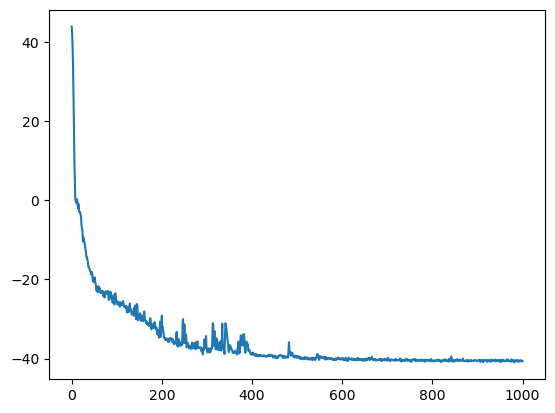

In [9]:
import matplotlib.pyplot as plt
fname=f'1d_J1J2_results_LorentzGRU_manifold_update_single_clamp/spatial_clamp={spatial_clamp}/J2={J2}'
# This notebook was closed by mistake but training still carried on. 
mE=np.load(f'{fname}/N100_J1=1.0|J2=0.8_100_LorentzGRU_70_ns=80_MsTrue_meanE.npy')
vE=np.load(f'{fname}/N100_J1=1.0|J2=0.8_100_LorentzGRU_70_ns=80_MsTrue_varE.npy')
print(np.min(mE), np.argmin(mE),vE[np.argmin(mE)], len(mE))
plt.plot(np.arange(len(mE)), mE)

## Spatial_clamp=5.0 (single)

In [4]:
# energy stalled at -40, but showed improvement compared to spatial_clamp=4.0
#Best model saved at epoch 906 with best E=-40.82932+0.14566j, varE=6.33131
spatial_clamp = 5.0
fname = f'1d_J1J2_results_LorentzGRU_manifold_update_single_clamp/spatial_clamp={spatial_clamp}/J2={J2}'

wf=Lorentzwavefunction(systemsize=syssize, cell_type='LorentzGRU', units=units,spatial_clamp=spatial_clamp, seed=111)
for name, param in wf.model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()}")
print(f'Total params ={sum(p.numel() for p in wf.model.parameters())}')
t0=time.time()
mE, vE = run_J1J2(wf, nsteps, syssize, var_tol, J1_=J1, J2_=J2, Marshall_sign=True, 
                   numsamples=nssamples, lr1=lr1, lr2=lr2, seed=111, fname=fname)
t1=time.time()
print(f'Time taken = {np.round((t1-t0)/3600,3)} hrs')

Layer: rnn.Wz | Size: torch.Size([70, 70])
Layer: rnn.Uz | Size: torch.Size([70, 2])
Layer: rnn.bz | Size: torch.Size([70])
Layer: rnn.Wr | Size: torch.Size([70, 70])
Layer: rnn.Ur | Size: torch.Size([70, 2])
Layer: rnn.br | Size: torch.Size([70])
Layer: rnn.Wh | Size: torch.Size([70, 70])
Layer: rnn.Uh | Size: torch.Size([70, 2])
Layer: rnn.bh | Size: torch.Size([70])
Layer: dense_a.weight | Size: torch.Size([2, 70])
Layer: dense_a.bias | Size: torch.Size([2])
Layer: dense_p.weight | Size: torch.Size([2, 70])
Layer: dense_p.bias | Size: torch.Size([2])
Layer: manifold.k | Size: torch.Size([])
Total params =15615


/opt/anaconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
/opt/anaconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1052: ComplexWarning: Casting complex values to real discards the imaginary part
  current = float(metrics)


step: 0, loss: -2.28125, mean energy: 43.96608-0.03309j|varE: 1.67621| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.05
max_h0 = 3.605502128601074 | max_h_spatial_norm = 3.464050054550171| max_h_violation = 3.814697265625e-06
Best model saved at epoch 1 with best E=42.56772-0.17841j, varE=5.86386
Best model saved at epoch 2 with best E=39.36857+0.53578j, varE=13.37966
step: 10, loss: 10.40009, mean energy: -0.26832+0.34121j|varE: 30.27268| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.0490000000000002
max_h0 = 3.414942979812622 | max_h_spatial_norm = 3.265246868133545| max_h_violation = 2.86102294921875e-06
step: 20, loss: 0.87514, mean energy: -3.63294+0.41421j|varE: 25.15471| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.048
max_h0 = 3.4819929599761963 | max_h_spatial_norm = 3.3353073596954346| max_h_violation = 4.76837158203125e-06
step: 30, loss: 4.54718, mean energy: -11.61355-0.11502j|varE: 40.31113| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.0470000000000002
max_h0 = 4.946611404418945 | max_h_spatial_norm =

## Spatial_clamp=4.0, single clamp in forward pass

In [5]:
# underperformed the tangent space model with spatial clamp =4.0: energy stalled at -39
#Best model saved at epoch 549 with best E=-40.15549+0.08691j, varE=3.00209
spatial_clamp = 4.0
#fname = f'1d_J1J2_results_N=100_single_clamp/LorentzGRU_manifold_update/sc_{spatial_clamp}/J2={J2}'
fname = f'1d_J1J2_results_LorentzGRU_manifold_update_single_clamp/spatial_clamp={spatial_clamp}/J2={J2}'

wf=Lorentzwavefunction(systemsize=syssize, cell_type='LorentzGRU', units=units,spatial_clamp=spatial_clamp, seed=111)
for name, param in wf.model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()}")
print(f'Total params ={sum(p.numel() for p in wf.model.parameters())}')
t0=time.time()
mE, vE = run_J1J2(wf, nsteps, syssize, var_tol, J1_=J1, J2_=J2, Marshall_sign=True, 
                   numsamples=nssamples, lr1=lr1, lr2=lr2, seed=111, fname=fname)
t1=time.time()
print(f'Time taken = {np.round((t1-t0)/3600,3)} hrs')

Layer: rnn.Wz | Size: torch.Size([70, 70])
Layer: rnn.Uz | Size: torch.Size([70, 2])
Layer: rnn.bz | Size: torch.Size([70])
Layer: rnn.Wr | Size: torch.Size([70, 70])
Layer: rnn.Ur | Size: torch.Size([70, 2])
Layer: rnn.br | Size: torch.Size([70])
Layer: rnn.Wh | Size: torch.Size([70, 70])
Layer: rnn.Uh | Size: torch.Size([70, 2])
Layer: rnn.bh | Size: torch.Size([70])
Layer: dense_a.weight | Size: torch.Size([2, 70])
Layer: dense_a.bias | Size: torch.Size([2])
Layer: dense_p.weight | Size: torch.Size([2, 70])
Layer: dense_p.bias | Size: torch.Size([2])
Layer: manifold.k | Size: torch.Size([])
Total params =15615


/Users/hl/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
/Users/hl/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:1052: ComplexWarning: Casting complex values to real discards the imaginary part
  current = float(metrics)


step: 0, loss: -2.28125, mean energy: 43.96608-0.03309j|varE: 1.67621| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.05
max_h0 = 3.605502128601074 | max_h_spatial_norm = 3.464050054550171| max_h_violation = 3.814697265625e-06
Best model saved at epoch 1 with best E=42.56772-0.17841j, varE=5.86386
Best model saved at epoch 2 with best E=39.36857+0.53578j, varE=13.37966
step: 10, loss: 10.40009, mean energy: -0.26832+0.34121j|varE: 30.27268| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.0490000000000002
max_h0 = 3.414942979812622 | max_h_spatial_norm = 3.265246868133545| max_h_violation = 2.86102294921875e-06
step: 20, loss: 0.87514, mean energy: -3.63294+0.41421j|varE: 25.15471| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.048
max_h0 = 3.4819929599761963 | max_h_spatial_norm = 3.3353073596954346| max_h_violation = 4.76837158203125e-06
step: 30, loss: 3.58002, mean energy: -11.51560-0.18596j|varE: 40.94773| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.0470000000000002
max_h0 = 4.474328517913818 | max_h_spatial_norm =

step: 230, loss: 3.54919, mean energy: -38.13911-0.07504j|varE: 11.27868| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.0270000000000001
max_h0 = 5.457642555236816 | max_h_spatial_norm = 5.365245342254639| max_h_violation = 7.62939453125e-06
Best model saved at epoch 237 with best E=-39.00134+0.28665j, varE=6.57302
step: 240, loss: 13.27502, mean energy: -38.14376-0.13856j|varE: 5.61834| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.026
max_h0 = 4.776452541351318 | max_h_spatial_norm = 4.670599460601807| max_h_violation = 7.62939453125e-06
step: 250, loss: 2.11963, mean energy: -37.88584-0.05038j|varE: 7.65954| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.0250000000000001
max_h0 = 4.862363815307617 | max_h_spatial_norm = 4.758422374725342| max_h_violation = 7.62939453125e-06
step: 260, loss: -6.03101, mean energy: -37.17621-0.19778j|varE: 12.31043| Hyp LR: 8.00e-03| LR: 5.00e-03| tau=1.024
max_h0 = 4.203232288360596 | max_h_spatial_norm = 4.08254337310791| max_h_violation = 2.86102294921875e-06
step: 270, lo

step: 560, loss: -0.31873, mean energy: -39.34644+0.10960j|varE: 4.67242| Hyp LR: 2.50e-04| LR: 1.56e-04| tau=1.0
max_h0 = 4.379274368286133 | max_h_spatial_norm = 4.263571739196777| max_h_violation = 5.7220458984375e-06
step: 570, loss: 2.41016, mean energy: -39.32571-0.03602j|varE: 3.31988| Hyp LR: 2.50e-04| LR: 1.56e-04| tau=1.0
max_h0 = 5.134722709655762 | max_h_spatial_norm = 5.036405086517334| max_h_violation = 7.62939453125e-06
step: 580, loss: -0.84827, mean energy: -39.79433+0.00241j|varE: 2.24415| Hyp LR: 2.50e-04| LR: 1.56e-04| tau=1.0
max_h0 = 4.3670220375061035 | max_h_spatial_norm = 4.250986099243164| max_h_violation = 5.7220458984375e-06
step: 590, loss: 1.87805, mean energy: -39.62811-0.00331j|varE: 2.41942| Hyp LR: 1.25e-04| LR: 7.81e-05| tau=1.0
max_h0 = 4.37391471862793 | max_h_spatial_norm = 4.258066177368164| max_h_violation = 5.7220458984375e-06
step: 600, loss: 0.84937, mean energy: -39.96218+0.02719j|varE: 1.89466| Hyp LR: 1.25e-04| LR: 7.81e-05| tau=1.0
max_h0 